In [111]:
import os

import json

import pandas as pd

from pandas.core.indexers import objects



# Define paths to the hard-mode raw files sitting on your laptop

SOCIAL_FILE = "C:\\Users\\yashi\\OneDrive\\Desktop\\Project_TCS\\source_social_media\\twitter_dump.csv"

ECOMM_FILE = "C:\\Users\\yashi\\OneDrive\\Desktop\\Project_TCS\\source_ecommerce\\web_reviews.json"

SUPPORT_FILE = "C:\\Users\\yashi\\OneDrive\\Desktop\\Project_TCS\\source_support_center\\support_logs.csv"



# This list will hold all records before we turn it into a single DataFrame

master_records = []



print("🔄 Starting multi-channel aggregation pipeline...\n")



# ---------------------------------------------------------------------

# CHANNEL 1: Ingesting Social Media (Twitter CSV)

# Schema: [timestamp, handle, tweet_text]

# ---------------------------------------------------------------------

if os.path.exists(SOCIAL_FILE):

    df_social = pd.read_csv(SOCIAL_FILE)

    df_social["clean_timestamp"] = pd.to_datetime(df_social["timestamp"], errors='coerce')

    for idx, row in df_social.iterrows():

        master_records.append({

            "customer_id": row["customer_id"],

            "timestamp": row["clean_timestamp"],            # Target 1: Time

            "channel": "Social Media (X/Twitter)",     # Target 2: Origin Source

            "raw_text": row["tweet_text"]             # Target 3: Clean Text

        })

    print(f"📥 Successfully aggregated {len(df_social)} records from Social Media.")



# ---------------------------------------------------------------------

# CHANNEL 2: Ingesting E-Commerce Reviews (JSON Array)

# Schema: [{"review_date": ..., "rating": ..., "body": ...}]

# ---------------------------------------------------------------------

if os.path.exists(ECOMM_FILE):

    with open(ECOMM_FILE, "r", encoding="utf-8") as f:

        ecomm_data = json.load(f)

       

    for item in ecomm_data:

        cleaned_dates = pd.to_datetime(item["review_date"], format="%d-%b-%Y", errors='coerce')

        master_records.append({

            "customer_id":item["customer_id"],

            "timestamp": cleaned_dates,         # Target 1: Time (Needs formatting later)

            "channel": "E-Commerce Website",          # Target 2: Origin Source

            "raw_text": item["body"]                  # Target 3: Clean Text

        })

    print(f"📥 Successfully aggregated {len(ecomm_data)} records from E-Commerce.")



# ---------------------------------------------------------------------

# CHANNEL 3: Ingesting Customer Support Center (Logs CSV)

# Schema: [date_string, transcript]

# ---------------------------------------------------------------------

if os.path.exists(SUPPORT_FILE):

    df_support = pd.read_csv(SUPPORT_FILE)

    df_support["clean_timestamp"] = pd.to_datetime(df_support["date_string"], errors='coerce')

    for idx,row in df_support.iterrows():

        master_records.append({

            "customer_id": row["customer_id"],

            "timestamp": row["clean_timestamp"],          # Target 1: Time

            "channel": "Call Center Transcript",      # Target 2: Origin Source

            "raw_text": row["transcript"]             # Target 3: Clean Text

        })

    print(f"📥 Successfully aggregated {len(df_support)} records from Support Logs.") 



🔄 Starting multi-channel aggregation pipeline...

📥 Successfully aggregated 664 records from Social Media.
📥 Successfully aggregated 692 records from E-Commerce.
📥 Successfully aggregated 605 records from Support Logs.


C:\Users\yashi\AppData\Local\Temp\ipykernel_13124\156501725.py:111: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_support["clean_timestamp"] = pd.to_datetime(df_support["date_string"], errors='coerce')


In [112]:
# Turn our unified list of dictionaries into a master Pandas DataFrame
df = pd.DataFrame(master_records)
df

,customer_id,timestamp,channel,raw_text
0,1112,2026-05-01 20:21:00,Social Media (X/Twitter),The associate handling my checkout helped me f...
1,1359,2026-05-01 13:09:00,Social Media (X/Twitter),The online availability tracker were fully sto...
2,1224,2026-05-01 10:52:00,Social Media (X/Twitter),The customer service representative was workin...
3,1271,2026-05-01 15:54:00,Social Media (X/Twitter),The main display in the center aisle had a few...
4,1050,2026-05-01 13:29:00,Social Media (X/Twitter),The mobile app cart page is incredibly intuiti...
...,...,...,...,...
1956,1377,2026-08-27 13:05:00,Call Center Transcript,The self-serve kiosk refused to read my barcod...
1957,1035,2026-08-28 19:48:00,Call Center Transcript,The customer service representative was incred...
1958,1350,2026-08-28 20:22:00,Call Center Transcript,The self-serve kiosk accepted the standard tap...
1959,1004,2026-08-28 09:51:00,Call Center Transcript,The standard delivery transit timeframe arrive...


In [113]:
df[df.channel == "E-Commerce Website"]

,customer_id,timestamp,channel,raw_text
664,1149,2026-05-01,E-Commerce Website,The stock levels for advertised sale items wer...
665,1292,2026-05-01,E-Commerce Website,The mobile app cart page accepted the standard...
666,1114,2026-05-01,E-Commerce Website,The physical shelves for the new collection lo...
667,1056,2026-05-01,E-Commerce Website,The customer service representative handled a ...
668,1383,2026-05-02,E-Commerce Website,The mobile app cart page processed my transact...
...,...,...,...,...
1351,1112,2026-08-28,E-Commerce Website,The associate handling my checkout helped me f...
1352,1041,2026-08-28,E-Commerce Website,The order confirmation system updated status o...
1353,1172,2026-08-28,E-Commerce Website,The associate handling my checkout stood aroun...
1354,1385,2026-08-28,E-Commerce Website,The floor staff working today stood around tal...


In [114]:
# Step 3: Sentiment Analysis Using Hugging Face Roberta Large English 3-classes Model
import torch
from transformers import pipeline
classifier = pipeline("text-classification", model = "j-hartmann/sentiment-roberta-large-english-3-classes", return_all_scores = True)


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 26057.76it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: j-hartmann/sentiment-roberta-large-english-3-classes
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [115]:
# Test 
classifier("This product was a lifesaver! My only complaint is that there are not a lot of colors!")

[{'label': 'positive', 'score': 0.9993636012077332}]

In [116]:
texts = df["raw_text"].tolist()
sentiment_results = classifier(texts)
sentiment_results

[{'label': 'positive', 'score': 0.9994133710861206},
 {'label': 'neutral', 'score': 0.7230466604232788},
 {'label': 'neutral', 'score': 0.9980424642562866},
 {'label': 'neutral', 'score': 0.9964410662651062},
 {'label': 'positive', 'score': 0.9978005290031433},
 {'label': 'negative', 'score': 0.9987572431564331},
 {'label': 'negative', 'score': 0.9989639520645142},
 {'label': 'positive', 'score': 0.9989460110664368},
 {'label': 'positive', 'score': 0.9551361203193665},
 {'label': 'neutral', 'score': 0.9973969459533691},
 {'label': 'neutral', 'score': 0.9988419413566589},
 {'label': 'negative', 'score': 0.9989363551139832},
 {'label': 'negative', 'score': 0.9980206489562988},
 {'label': 'neutral', 'score': 0.9982411861419678},
 {'label': 'positive', 'score': 0.9994458556175232},
 {'label': 'positive', 'score': 0.9994133710861206},
 {'label': 'positive', 'score': 0.9995619654655457},
 {'label': 'positive', 'score': 0.9988142251968384},
 {'label': 'positive', 'score': 0.9314290285110474},

In [117]:
df["sentiment"] = [r["label"] for r in sentiment_results]
df

,customer_id,timestamp,channel,raw_text,sentiment
0,1112,2026-05-01 20:21:00,Social Media (X/Twitter),The associate handling my checkout helped me f...,positive
1,1359,2026-05-01 13:09:00,Social Media (X/Twitter),The online availability tracker were fully sto...,neutral
2,1224,2026-05-01 10:52:00,Social Media (X/Twitter),The customer service representative was workin...,neutral
3,1271,2026-05-01 15:54:00,Social Media (X/Twitter),The main display in the center aisle had a few...,neutral
4,1050,2026-05-01 13:29:00,Social Media (X/Twitter),The mobile app cart page is incredibly intuiti...,positive
...,...,...,...,...,...
1956,1377,2026-08-27 13:05:00,Call Center Transcript,The self-serve kiosk refused to read my barcod...,negative
1957,1035,2026-08-28 19:48:00,Call Center Transcript,The customer service representative was incred...,positive
1958,1350,2026-08-28 20:22:00,Call Center Transcript,The self-serve kiosk accepted the standard tap...,positive
1959,1004,2026-08-28 09:51:00,Call Center Transcript,The standard delivery transit timeframe arrive...,positive


In [118]:
df["sentiment_confidence"] = [r["score"] for r in sentiment_results]

In [119]:
# Step ##: We can do a deeper dive into sentiments by looking specifically at emotions
emotion_classifier = pipeline("text-classification", model = "j-hartmann/emotion-english-distilroberta-base")
important_texts = df["raw_text"].tolist()
emotion_results = emotion_classifier(important_texts)

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 12682.56it/s]


In [120]:
emotion_results

[{'label': 'joy', 'score': 0.5296657681465149},
 {'label': 'neutral', 'score': 0.7361800670623779},
 {'label': 'neutral', 'score': 0.828447163105011},
 {'label': 'neutral', 'score': 0.9219479560852051},
 {'label': 'neutral', 'score': 0.806087851524353},
 {'label': 'sadness', 'score': 0.37659555673599243},
 {'label': 'neutral', 'score': 0.629237711429596},
 {'label': 'neutral', 'score': 0.8125238418579102},
 {'label': 'neutral', 'score': 0.8143256306648254},
 {'label': 'neutral', 'score': 0.8864479660987854},
 {'label': 'neutral', 'score': 0.8299746513366699},
 {'label': 'anger', 'score': 0.5097772479057312},
 {'label': 'neutral', 'score': 0.36861538887023926},
 {'label': 'neutral', 'score': 0.9690172672271729},
 {'label': 'neutral', 'score': 0.4820183217525482},
 {'label': 'joy', 'score': 0.5296657681465149},
 {'label': 'neutral', 'score': 0.4949289858341217},
 {'label': 'neutral', 'score': 0.7380223870277405},
 {'label': 'neutral', 'score': 0.7113097310066223},
 {'label': 'neutral', '

In [121]:
df["emotion"] = [r["label"] for r in emotion_results]
df

,customer_id,timestamp,channel,raw_text,sentiment,sentiment_confidence,emotion
0,1112,2026-05-01 20:21:00,Social Media (X/Twitter),The associate handling my checkout helped me f...,positive,0.999413,joy
1,1359,2026-05-01 13:09:00,Social Media (X/Twitter),The online availability tracker were fully sto...,neutral,0.723047,neutral
2,1224,2026-05-01 10:52:00,Social Media (X/Twitter),The customer service representative was workin...,neutral,0.998042,neutral
3,1271,2026-05-01 15:54:00,Social Media (X/Twitter),The main display in the center aisle had a few...,neutral,0.996441,neutral
4,1050,2026-05-01 13:29:00,Social Media (X/Twitter),The mobile app cart page is incredibly intuiti...,positive,0.997801,neutral
...,...,...,...,...,...,...,...
1956,1377,2026-08-27 13:05:00,Call Center Transcript,The self-serve kiosk refused to read my barcod...,negative,0.998932,anger
1957,1035,2026-08-28 19:48:00,Call Center Transcript,The customer service representative was incred...,positive,0.999615,joy
1958,1350,2026-08-28 20:22:00,Call Center Transcript,The self-serve kiosk accepted the standard tap...,positive,0.997407,neutral
1959,1004,2026-08-28 09:51:00,Call Center Transcript,The standard delivery transit timeframe arrive...,positive,0.994134,neutral


In [122]:
df["emotion_confidence"] = [r["score"] for r in emotion_results]

In [123]:
# Step 5: Now we can move onto modeling aspect of this assignment, but first we need to make numerical representations of our data using vector embeddings
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(df["raw_text"].tolist())

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3300.96it/s]


In [124]:
df_embeddings = pd.DataFrame(embeddings)
df_embeddings

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,-0.002533,-0.007125,-0.037225,0.040794,-0.030154,0.021871,0.008614,-0.094341,-0.050776,-0.076221,...,0.019251,-0.047173,-0.021658,-0.082920,0.073789,0.050654,-0.012244,0.009863,-0.016913,0.017425
1,-0.005863,-0.075374,0.012182,0.026762,0.120606,-0.000113,-0.006604,-0.021092,-0.115652,-0.035763,...,0.025021,-0.020752,0.002034,-0.071008,0.064039,0.027552,-0.012844,-0.023019,0.017752,-0.001980
2,-0.041739,-0.025404,0.007066,0.023245,-0.007760,-0.070708,-0.015188,-0.030894,0.002452,-0.055796,...,0.059386,0.001918,0.043246,-0.028780,0.004857,0.015947,0.027225,-0.006277,-0.066023,0.017891
3,0.016945,0.023177,-0.065038,-0.029084,-0.023325,0.055922,-0.099354,0.052836,-0.009844,-0.002686,...,0.000392,-0.017453,0.095957,0.006023,0.010890,0.035387,0.052242,0.050419,-0.059402,0.113512
4,-0.084489,0.050603,0.085432,0.019671,-0.002056,-0.042412,-0.082552,0.005463,-0.038459,0.058068,...,0.073455,0.026881,0.036704,-0.067237,0.060037,0.049142,0.090688,0.073656,-0.014084,-0.047447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1956,0.032932,0.032902,-0.015417,-0.073994,-0.061273,-0.012598,-0.074692,-0.062017,0.023938,-0.002714,...,0.100169,-0.009679,-0.033017,-0.058625,0.003851,0.050895,0.102942,0.022227,-0.067208,-0.005990
1957,-0.094012,0.025421,0.056203,-0.030201,0.012731,-0.018287,0.023196,-0.063391,-0.005857,-0.044897,...,0.003630,-0.028454,-0.037889,-0.010511,0.009671,0.084690,0.001926,0.003070,-0.031314,0.011099
1958,-0.089381,0.059886,0.016689,-0.046769,-0.091140,-0.066281,0.072926,-0.015385,0.007423,-0.005704,...,0.097191,-0.018371,0.041937,-0.037393,0.087074,0.061922,0.112654,0.014686,-0.025628,0.066856
1959,-0.008189,-0.080797,0.069130,0.022516,-0.007812,-0.031112,-0.158507,-0.033553,-0.009110,0.004510,...,0.102419,-0.054985,-0.016737,-0.047669,0.072244,0.064649,0.011716,-0.016394,-0.003278,-0.019831


In [125]:
# Step 6: Now we can use vector embeddings to cluster our feedback into distinct categories. We will use the HDBSCAN clustering method. 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN
cluster_model = HDBSCAN(min_cluster_size=60, metric='cosine')


In [126]:
labels = cluster_model.fit_predict(embeddings)
labels

array([ 0,  1, -1, ...,  2,  3,  2])

In [127]:
np.unique(labels)

array([-1,  0,  1,  2,  3])

In [128]:
df_labels = pd.DataFrame(labels, columns = ["label"])
len(df_labels[df_labels.label == -1]) / len(df_labels)

0.15961244263131055

In [129]:
len(df_labels["label"].unique())

5

In [130]:
# Plotting, but for dimensionality reduction must reduce embeddings to 2D using PCA
from sklearn.decomposition import PCA
components = PCA(n_components=2).fit_transform(embeddings)

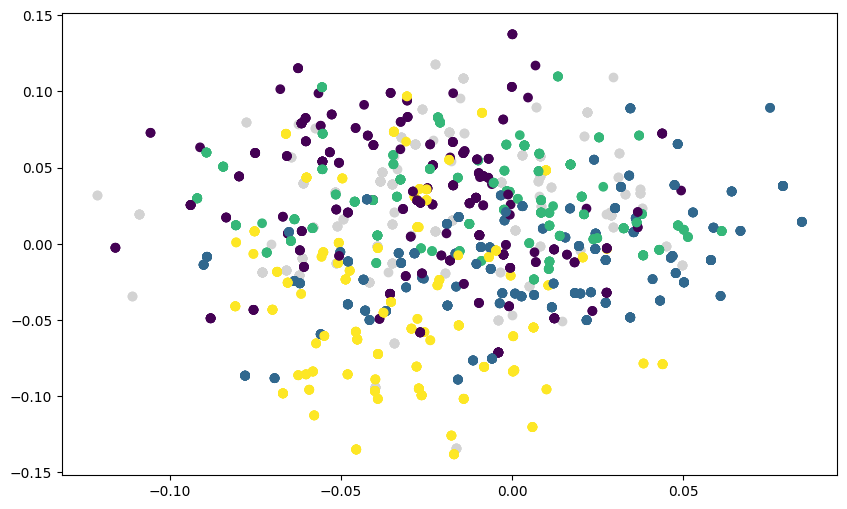

In [131]:
noise = labels == -1
plt.figure(figsize = (10,6))
plt.scatter(embeddings[noise,0], embeddings[noise,1], color = "lightgray", label = "Noise")
plt.scatter(embeddings[~noise,0], embeddings[~noise,1], c = labels[~noise],label = "Cluster")


In [132]:
df_labels

,label
0,0
1,1
2,-1
3,1
4,2
...,...
1956,-1
1957,0
1958,2
1959,3


In [133]:
df["cluster"] = labels
df

,customer_id,timestamp,channel,raw_text,sentiment,sentiment_confidence,emotion,emotion_confidence,cluster
0,1112,2026-05-01 20:21:00,Social Media (X/Twitter),The associate handling my checkout helped me f...,positive,0.999413,joy,0.529666,0
1,1359,2026-05-01 13:09:00,Social Media (X/Twitter),The online availability tracker were fully sto...,neutral,0.723047,neutral,0.736180,1
2,1224,2026-05-01 10:52:00,Social Media (X/Twitter),The customer service representative was workin...,neutral,0.998042,neutral,0.828447,-1
3,1271,2026-05-01 15:54:00,Social Media (X/Twitter),The main display in the center aisle had a few...,neutral,0.996441,neutral,0.921948,1
4,1050,2026-05-01 13:29:00,Social Media (X/Twitter),The mobile app cart page is incredibly intuiti...,positive,0.997801,neutral,0.806088,2
...,...,...,...,...,...,...,...,...,...
1956,1377,2026-08-27 13:05:00,Call Center Transcript,The self-serve kiosk refused to read my barcod...,negative,0.998932,anger,0.699024,-1
1957,1035,2026-08-28 19:48:00,Call Center Transcript,The customer service representative was incred...,positive,0.999615,joy,0.612988,0
1958,1350,2026-08-28 20:22:00,Call Center Transcript,The self-serve kiosk accepted the standard tap...,positive,0.997407,neutral,0.723035,2
1959,1004,2026-08-28 09:51:00,Call Center Transcript,The standard delivery transit timeframe arrive...,positive,0.994134,neutral,0.556757,3


In [134]:
df["cluster"].unique()

array([ 0,  1, -1,  2,  3])

In [135]:
# Remove noise
df = df[df.cluster != -1]
df

,customer_id,timestamp,channel,raw_text,sentiment,sentiment_confidence,emotion,emotion_confidence,cluster
0,1112,2026-05-01 20:21:00,Social Media (X/Twitter),The associate handling my checkout helped me f...,positive,0.999413,joy,0.529666,0
1,1359,2026-05-01 13:09:00,Social Media (X/Twitter),The online availability tracker were fully sto...,neutral,0.723047,neutral,0.736180,1
3,1271,2026-05-01 15:54:00,Social Media (X/Twitter),The main display in the center aisle had a few...,neutral,0.996441,neutral,0.921948,1
4,1050,2026-05-01 13:29:00,Social Media (X/Twitter),The mobile app cart page is incredibly intuiti...,positive,0.997801,neutral,0.806088,2
5,1264,2026-05-02 12:19:00,Social Media (X/Twitter),The digital checkout screen would not let me p...,negative,0.998757,sadness,0.376596,2
...,...,...,...,...,...,...,...,...,...
1955,1171,2026-08-27 14:39:00,Call Center Transcript,The standard delivery transit timeframe kept t...,positive,0.692768,neutral,0.955730,3
1957,1035,2026-08-28 19:48:00,Call Center Transcript,The customer service representative was incred...,positive,0.999615,joy,0.612988,0
1958,1350,2026-08-28 20:22:00,Call Center Transcript,The self-serve kiosk accepted the standard tap...,positive,0.997407,neutral,0.723035,2
1959,1004,2026-08-28 09:51:00,Call Center Transcript,The standard delivery transit timeframe arrive...,positive,0.994134,neutral,0.556757,3


In [136]:
# Step 6: We now have the clusters, so we can do further textual analysis to find the common themes, and identify a tag
from keybert import KeyBERT
kw_model = KeyBERT()
cluster_kw = {}
for cid in sorted(df["cluster"].unique()):
    texts = df.loc[df["cluster"] == cid, "raw_text"].tolist()
    keywords = kw_model.extract_keywords(texts, keyphrase_ngram_range=(1, 3), top_n=8)
    cluster_kw[cid] = keywords
cluster_kw

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3457.19it/s]


{np.int64(0): [[('associate handling checkout', 0.6195),
   ('checkout helped', 0.5008),
   ('highly recommend location', 0.4945),
   ('checkout', 0.4849),
   ('handling checkout helped', 0.4789),
   ('recommend location', 0.463),
   ('handling checkout', 0.4606),
   ('checkout helped instantly', 0.4592)],
  [('floor staff working', 0.602),
   ('floor staff', 0.5653),
   ('highly recommend location', 0.5276),
   ('floor', 0.4666),
   ('recommend location', 0.4598),
   ('request routinely', 0.3997),
   ('staff working today', 0.3936),
   ('request routinely highly', 0.3919)],
  [('service representative working', 0.4183),
   ('customer service representative', 0.3921),
   ('pace issues report', 0.3802),
   ('representative working average', 0.3438),
   ('average pace issues', 0.3302),
   ('working average pace', 0.3189),
   ('representative working', 0.3166),
   ('service representative', 0.3154)],
  [('cashier counter handled', 0.6536),
   ('cashier counter', 0.569),
   ('cashier', 0.5

In [137]:
themes = {
    "Delivery": ["tracking", "delivery", "shipping", "package", "arrived", "delayed", "crushed", "transit"],
    "Inventory": ["shelves", "catalog", "stock", "out of stock", "availability", "empty", "disorganized", "inventory"],
    "Staff": ["staff", "cashier", "representative", "associate", "coworkers", "rude", "polite", "welcoming"],
    "Technology": ["loading", "crashing", "kiosk", "mobile app", "screen", "payment", "barcode", "confirm button"]
}
def map_cluster_to_theme(cluster_kw):
    cluster_theme = {}
    for cid, kws in cluster_kw.items():
        kws_join = " ".join([str(k).lower() for k in kws])

        best_theme, best_score = None, -1
        for theme, rule_keywords in themes.items():
            score = sum(1 for rk in rule_keywords if rk.lower() in kws_join)
            if score > best_score:
                best_theme, best_score = theme, score

        # fallback: if no rule hits, label as Other/Unknown
        cluster_theme[cid] = best_theme if best_score > 0 else "Other"
    return cluster_theme

cluster_theme = map_cluster_to_theme(cluster_kw)

In [138]:
df["label"] = df["cluster"].map(cluster_theme)
df

C:\Users\yashi\AppData\Local\Temp\ipykernel_13124\3119894715.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = df["cluster"].map(cluster_theme)


,customer_id,timestamp,channel,raw_text,sentiment,sentiment_confidence,emotion,emotion_confidence,cluster,label
0,1112,2026-05-01 20:21:00,Social Media (X/Twitter),The associate handling my checkout helped me f...,positive,0.999413,joy,0.529666,0,Staff
1,1359,2026-05-01 13:09:00,Social Media (X/Twitter),The online availability tracker were fully sto...,neutral,0.723047,neutral,0.736180,1,Inventory
3,1271,2026-05-01 15:54:00,Social Media (X/Twitter),The main display in the center aisle had a few...,neutral,0.996441,neutral,0.921948,1,Inventory
4,1050,2026-05-01 13:29:00,Social Media (X/Twitter),The mobile app cart page is incredibly intuiti...,positive,0.997801,neutral,0.806088,2,Technology
5,1264,2026-05-02 12:19:00,Social Media (X/Twitter),The digital checkout screen would not let me p...,negative,0.998757,sadness,0.376596,2,Technology
...,...,...,...,...,...,...,...,...,...,...
1955,1171,2026-08-27 14:39:00,Call Center Transcript,The standard delivery transit timeframe kept t...,positive,0.692768,neutral,0.955730,3,Delivery
1957,1035,2026-08-28 19:48:00,Call Center Transcript,The customer service representative was incred...,positive,0.999615,joy,0.612988,0,Staff
1958,1350,2026-08-28 20:22:00,Call Center Transcript,The self-serve kiosk accepted the standard tap...,positive,0.997407,neutral,0.723035,2,Technology
1959,1004,2026-08-28 09:51:00,Call Center Transcript,The standard delivery transit timeframe arrive...,positive,0.994134,neutral,0.556757,3,Delivery


In [ ]:
# Recommendations
recommendations = {
    "Shipping":  {
        "low":    "Improve delivery experience with clearer ETAs and better tracking communication",
        "medium": "Investigate recurring shipping issues; improve ETA accuracy and improve notifications.",
        "high":   "Prioritize shipping failures/delays: fix tracking issues, address broken shipments, and escalate carrier exceptions."
    },
    "Inventory": {
        "low":    "Improve availability by aligning online listings with real stock and capitalize on social media trends.",
        "medium": "Audit stock accuracy and reduce oversell; update availability faster.",
        "high":   "Investigate availability mismatches and improve replenishment processes."
    },
    "Staff": {
        "low":    "Reinforce good service practices and reward staff members for their hard work.",
        "medium": "Target service gaps: investigate store operations and improve staffing during peak hours.",
        "high":   "Improve employee efficiency and morale: create detailed training programs, investigate staffing levels"
    },
    "Technology": {
        "low":    "Focus on minor usability changes to boost purchases",
        "medium": "Improve reliability and error recovery paths.",
        "high":   "Stop critical failures (crashes/loading/payment flows): deep-dive logs, add monitoring/alerts, and implement fixes immediately."
    },
}

In [140]:
issue_summary = (
    df.groupby("label")
      .agg(
          volume=("label", "size"),
          negative_pct=(
              "sentiment",
              lambda x: (x == "negative").mean()
          )
      )
      .reset_index()
)

In [141]:
def determine_severity(negative_pct):

    if negative_pct >= 0.75:
        return "high"

    elif negative_pct >= 0.50:
        return "medium"

    else:
        return "low"

In [142]:
def get_recommendation(row):

    label = row["label"]

    severity = determine_severity(
        row["negative_pct"]
    )

    if label in recommendations:
        return recommendations[label][severity]

    return "Continue monitoring customer feedback."

In [149]:
issue_summary["recommendation"] = (
    issue_summary.apply(
        get_recommendation,
        axis=1
    )
)
issue_summary

,label,volume,negative_pct,recommendation
0,Delivery,414,0.311594,Continue monitoring customer feedback.
1,Inventory,534,0.380150,Improve availability by aligning online listin...
2,Staff,338,0.251479,Reinforce good service practices and reward st...
3,Technology,362,0.533149,Improve reliability and error recovery paths.


In [152]:
df = df.merge(issue_summary[["label", "recommendation"]], on = "label", how = "left")
df

,customer_id,timestamp,channel,raw_text,sentiment,sentiment_confidence,emotion,emotion_confidence,cluster,label,recommendation
0,1112,2026-05-01 20:21:00,Social Media (X/Twitter),The associate handling my checkout helped me f...,positive,0.999413,joy,0.529666,0,Staff,Reinforce good service practices and reward st...
1,1359,2026-05-01 13:09:00,Social Media (X/Twitter),The online availability tracker were fully sto...,neutral,0.723047,neutral,0.736180,1,Inventory,Improve availability by aligning online listin...
2,1271,2026-05-01 15:54:00,Social Media (X/Twitter),The main display in the center aisle had a few...,neutral,0.996441,neutral,0.921948,1,Inventory,Improve availability by aligning online listin...
3,1050,2026-05-01 13:29:00,Social Media (X/Twitter),The mobile app cart page is incredibly intuiti...,positive,0.997801,neutral,0.806088,2,Technology,Improve reliability and error recovery paths.
4,1264,2026-05-02 12:19:00,Social Media (X/Twitter),The digital checkout screen would not let me p...,negative,0.998757,sadness,0.376596,2,Technology,Improve reliability and error recovery paths.
...,...,...,...,...,...,...,...,...,...,...,...
1643,1171,2026-08-27 14:39:00,Call Center Transcript,The standard delivery transit timeframe kept t...,positive,0.692768,neutral,0.955730,3,Delivery,Continue monitoring customer feedback.
1644,1035,2026-08-28 19:48:00,Call Center Transcript,The customer service representative was incred...,positive,0.999615,joy,0.612988,0,Staff,Reinforce good service practices and reward st...
1645,1350,2026-08-28 20:22:00,Call Center Transcript,The self-serve kiosk accepted the standard tap...,positive,0.997407,neutral,0.723035,2,Technology,Improve reliability and error recovery paths.
1646,1004,2026-08-28 09:51:00,Call Center Transcript,The standard delivery transit timeframe arrive...,positive,0.994134,neutral,0.556757,3,Delivery,Continue monitoring customer feedback.


In [153]:
## We will Save our CSV so then we can do dashboarding
csv = df.to_csv("Customer_insight.csv", index = False)